In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from pathlib import Path
# from preproces_prod3 import *
from preproces_prod4_2025_update import *
warnings.filterwarnings("ignore")

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

path_actual = Path.cwd()
path_data = path_actual.parent/'Data' 

In [ ]:
cohorte = pd.read_csv(path_data / 'COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv', encoding = "latin-1", sep = ";")

In [3]:
df_pf = pre_filtred(df_name = path_data / 'COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv') # 'NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr' 'COHORTE_NIRSE_ACTUALIZADA_23_06_2025_ENCR
# df_f_any, df_f_LRTI, df_f_vrs, df_f_upc = filtros_IH_new(df_pf)

_, _, df_f_vrs, _ = filtros_IH_new(df_pf,
                                   eliminar_inmunes_pre_season=True, 
                                   T_inicial = pd.to_datetime('2025-03-01'), 
                                   fecha_dt = pd.to_datetime('2025-08-01'),
                                   duracion_dias_nirse=180,
                                   meses_inm=None,
                                   ef_2024_in_2025=False,
                                   fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                   fecha_cohort_out = pd.to_datetime('2025-08-30'))

df_f_vrs = df_f_vrs.assign(season_ing = lambda df: np.where(df.fecha_nac.dt.month<=9,df.fecha_nac.dt.year, df.fecha_nac.dt.year+1).astype(int)).query('season_ing>0')
columns = ['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado','event_vrs','season_ing']
df = df_f_vrs[columns].copy().query('days_estad_vrs<35')
df.to_csv(path_data/'graficos_felipe_nirse.csv', index=False)
df_f_vrs = (df_f_vrs
            .assign(ola_enfermedad=lambda df: ((df.fechaIng_any.dt.month.between(4, 9)) & (df.fechaIng_any.dt.year==2024)) | ((df.fechaIng_any.dt.month.between(3, 9)) & (df.fechaIng_any.dt.year==2025)),
                    ano_ing = lambda df: df.fechaIng_any.dt.year))

n_rows_inicial= 338452
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 338452
Datos perdidos por muertes:  1012
ruts perdidos por filtro semanas y peso:  502
Droped intersex: 3
Datos perdidos por edad madre atípica: 240
Datos perdidos por fecha ingreso menor a fecha nacimiento: 11
vrs en los primeros 7 dias de

In [11]:
_, _, df_f_vrs, _ = filtros_IH_new(df_pf,
                                   eliminar_inmunes_pre_season=True, 
                                   T_inicial = pd.to_datetime('2024-04-01'), 
                                   fecha_dt = pd.to_datetime('2025-09-01'),
                                   duracion_dias_nirse=180,
                                   meses_inm=None,
                                   ef_2024_in_2025=True,
                                   fecha_cohort_in = pd.to_datetime('2023-10-01'),
                                   fecha_cohort_out = pd.to_datetime('2025-09-30'))

df_f_vrs = df_f_vrs.assign(season_ing = lambda df: np.where(df.fecha_nac.dt.month<=9,df.fecha_nac.dt.year, df.fecha_nac.dt.year+1).astype(int)).query('season_ing>0')
columns = ['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado','event_vrs','season_ing']
df = df_f_vrs[columns].copy().query('days_estad_vrs<35')
df.to_csv(path_data/'graficos_felipe_nirse.csv', index=False)
df_f_vrs = (df_f_vrs
            .assign(ola_enfermedad=lambda df: ((df.fechaIng_any.dt.month.between(4, 9)) & (df.fechaIng_any.dt.year==2024)) | ((df.fechaIng_any.dt.month.between(3, 9)) & (df.fechaIng_any.dt.year==2025)),
                    ano_ing = lambda df: df.fechaIng_any.dt.year))

Datos perdidos por muertes:  2649
ruts perdidos por filtro semanas y peso:  1083
Droped intersex: 36
Datos perdidos por edad madre atípica: 477
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias de nacer: 4
Ruts eliminados: 21406
fechaIng_vrs Reemplazos n/a net 7 days inmunizado:  33
fecha_upc_vrs Reemplazos n/a net 7 days inmunizado:  33
fechaIng_LRTI Reemplazos n/a net 7 days inmunizado:  46
fechaIng_any Reemplazos n/a net 7 days inmunizado:  923
max_meses_inm = 5


In [43]:
vector_cols = df_pf.columns

In [46]:
vector_cols_up = [col for col in vector_cols if not col in (['SER_CLIN_I', 'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS',
       'SERC_1_TRAS', 'DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS',
       'SERC_2_TRAS', 'DIA_3_TRAS', 'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS',
       'SERC_3_TRAS', 'DIA_4_TRAS', 'MES_4_TRAS', 'ANO_4_TRAS', 'AREAF_4_TRAS',
       'SERC_4_TRAS', 'DIA_5_TRAS', 'MES_5_TRAS', 'ANO_5_TRAS', 'AREAF_5_TRAS',
       'SERC_5_TRAS', 'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS', 'AREAF_6_TRAS',
       'SERC_6_TRAS', 'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS', 'AREAF_7_TRAS',
       'SERC_7_TRAS', 'DIA_8_TRAS', 'MES_8_TRAS', 'ANO_8_TRAS', 'AREAF_8_TRAS',
       'SERC_8_TRAS', 'DIA_9_TRAS', 'MES_9_TRAS', 'ANO_9_TRAS', 'AREAF_9_TRAS',
       'SERC_9_TRAS',])]

In [86]:
df_pf_edit = (df_pf[vector_cols_up]
              .assign(ola_enfermedad=lambda df: ((df.fechaIng_any.dt.month.between(4, 9)) & (df.fechaIng_any.dt.year==2024)) | ((df.fechaIng_any.dt.month.between(3, 9)) & (df.fechaIng_any.dt.year==2025)),
                      ano_ing = lambda df: df.fechaIng_any.dt.year,
                      egreso = lambda df: df.fechaIng_any.notna(),
                      season_ano = lambda df: np.where(df.fecha_nac.dt.month<=9,df.fecha_nac.dt.year, df.fecha_nac.dt.year+1).astype(int),)
              .query(('season_ano>0')))

In [ ]:
(df_pf_edit[['RUN','fecha_nac','season_ano','ola_enfermedad','ano_ing','VRS_D1','egreso','fechaInm']]
 .query('ola_enfermedad | ~egreso')
 .groupby(['season_ano','egreso'])
 .RUN.count()
 .unstack()
 .reset_index(drop=True)
 .assign( )
)

egreso,False,True
0,111258,24507
1,81916,5510


In [38]:
df_pf.RUN.nunique()

242767

In [7]:
df_f_vrs = (df_f_vrs
            .assign(ola_enfermedad=lambda df: ((df.fechaIng_any.dt.month.between(4, 9)) & (df.fechaIng_any.dt.year==2024)) | ((df.fechaIng_any.dt.month.between(3, 9)) & (df.fechaIng_any.dt.year==2025)),
                    ano_ing = lambda df: df.fechaIng_any.dt.year,
                    season_ano = lambda df: np.where(df.fecha_nac.dt.month<=9,df.fecha_nac.dt.year, df.fecha_nac.dt.year+1),))

In [57]:
df_pf[['RUN','FECHA_INGRESO','fechaIng_any']]

,RUN,FECHA_INGRESO,fechaIng_any
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,NaN,NaT
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,NaN,NaT
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc84...,01Oct2023,2023-10-01
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d...,02Dec2023,2023-12-02
4,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d...,01Oct2023,2023-10-01
...,...,...,...
257919,9b5023111cc565beca60f4da63a1632c08ba3d83fbb800...,NaN,NaT
257920,ecc5cd9c99b5d9eaca11886a3469de56213f6be410aa92...,NaN,NaT
257921,f872e4e73e9d72365a05a3b8e2e67f2e62d27439e61426...,NaN,NaT
257922,461464605882a3975fb7481837848ca20d46cf21583bfc...,NaN,NaT


In [58]:
df_f_vrs[['RUN','FECHA_INGRESO','fechaIng_any']]

,RUN,FECHA_INGRESO,fechaIng_any
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,NaN,NaT
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,NaN,NaT
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc84...,01Oct2023,NaT
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d...,02Dec2023,2023-12-02
5,d53f2b2a19d155d0c7f40764f00116abec55135bc49874...,NaN,NaT
...,...,...,...
234945,81d211dacaf66df3f5759e301a3558e5baa3d3fbd00418...,24May2025,2025-05-24
6449,4d6bbe4714c849b57323a84f674a399f4afb026f6f46e7...,26May2025,2025-05-26
76253,320ea3ac5e3febc493d0359ac7ad3eba67ee23a4c483f2...,26May2025,2025-05-26
221633,ad91a54e4cad44a18f0bdcd90cd000b3064834e7f6c1b0...,27May2025,2025-05-27


In [ ]:
path_actual = Path.cwd()
path_data = path_actual.parent/'Data' 
df_pf = pre_filtred(df_name = path_data / 'NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv') # 'NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr'
df_f_any, df_f_LRTI, df_f_vrs, df_f_upc = filtros_IH_new(df_pf)
columns = ['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado','event_vrs']
df = df_f_vrs[columns].copy()#.query('days_estad_vrs<35')
df.to_csv(path_data/'graficos_felipe_nirse.csv', index=False)

n_rows_inicial= 157557
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 157557
Datos perdidos por muertes:  1227
ruts perdidos por filtro semanas y peso:  491
Droped intersex: 14
Datos perdidos por edad madre atípica: 2
Datos perdidos por fecha ingreso menor a fecha nacimiento: 19
vrs en los primeros 7 dias de 

In [5]:
columns = ['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado','event_vrs']
df = df_f_vrs[columns].copy()#.query('days_estad_vrs<35')
df.to_csv(path_data/'graficos_felipe_nirse.csv', index=False)

In [6]:
df.query('days_estad_vrs>35')

,RUN,days_estad_vrs,days_upc_vrs,inmunizado,event_vrs
31584,be4b01bf4d9aa6384d1f058ee8287fb9c3adfbc0adb9fb...,46.0,10,1,1
10444,853945f2896309af07eeb35c4090a2cf2ebde6606e41a8...,39.0,22,1,1
107603,4cd1001b33a403c1fe50ddc9031849d961e0ce5523acd5...,37.0,9,1,1
1589,cee0de5152d8537a8d0786397ff148650c020281c27d57...,41.0,0,1,1
45888,4b180988170dece0c4c2fdfc8bf7ef2c08b1c34154f6a0...,38.0,33,1,0


In [32]:
df.query('days_upc_vrs>35')

,RUN,days_estad_vrs,days_upc_vrs,inmunizado,event_vrs
16989,22d892547f28bea1050ad2631275407a6bd2b2e2a7f7ae...,85.0,85,0,1
50088,80664c6f964bc826571f7b7851a7267310cc8c47d26e43...,44.0,44,0,1


In [4]:
df = df[columns].copy().assign(days_estad_vrs = lambda x: np.where(x.days_estad_vrs>35, 35, x.days_estad_vrs),
                                           days_upc_vrs = lambda x: np.where(x.days_upc_vrs>35, 35, x.days_upc_vrs))
df.to_csv(path_data/'graficos_felipe_nirse.csv', index=False)

In [ ]:
# columns = ['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado']
# df_vrs = df_vrs_tilweek[columns].copy()
# df_upc = df_vrs_tilweek[columns].copy()


In [31]:
df_f_vrs.columns[5:95]

Index(['FECHA_NACIMIENTO', 'MES_NAC', 'ANO_NAC', 'SEXO', 'SEMANAS', 'PESO',
       'TALLA', 'EDAD_M', 'INS_C_M', 'INS_N_M', 'COMUNA', 'COMUNA_N',
       'REG_RES', 'URBA_RURAL', 'NAC_MA', 'FECHA_INMUNIZACION',
       'FECHA_DEFUNCION', 'CAUSA_DEFUNCION', 'VIVO', 'FALLECIDO_PREVIO',
       'ESTAB', 'ServicioSalud', 'Seremi', 'P_ORIGEN', 'PREVI',
       'FECHA_INGRESO', 'FECHA_EGRESO', 'AREA_FUNC_I', 'SER_CLIN_I',
       'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS', 'SERC_1_TRAS',
       'DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS', 'SERC_2_TRAS',
       'DIA_3_TRAS', 'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS', 'SERC_3_TRAS',
       'DIA_4_TRAS', 'MES_4_TRAS', 'ANO_4_TRAS', 'AREAF_4_TRAS', 'SERC_4_TRAS',
       'DIA_5_TRAS', 'MES_5_TRAS', 'ANO_5_TRAS', 'AREAF_5_TRAS', 'SERC_5_TRAS',
       'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS', 'AREAF_6_TRAS', 'SERC_6_TRAS',
       'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS', 'AREAF_7_TRAS', 'SERC_7_TRAS',
       'DIA_8_TRAS', 'ME

In [34]:
df_f_vrs.fechaIng_any.dt.year

0            NaN
1            NaN
2            NaN
3         2023.0
5            NaN
           ...  
234945       NaN
6449         NaN
76253        NaN
221633       NaN
70508        NaN
Name: fechaIng_any, Length: 239641, dtype: float64

In [46]:
df_f_vrs.assign(ano_ing = lambda df: df.fechaIng_any.dt.year).ano_ing.value_counts()

ano_ing
2024.0    8814
2023.0    1115
Name: count, dtype: int64

In [21]:
df_f_vrs = df_f_vrs.assign(ola_enfermedad=lambda df: ((df.fechaIng_any.dt.month.between(4, 9)) & (df.fechaIng_any.dt.year==2024)) | ((df.fechaIng_any.dt.month.between(3, 9)) & (df.fechaIng_any.dt.year==2025)))

In [22]:
df_f_vrs = df_f_vrs.assign(ano_ing = lambda df: df.fechaIng_any.dt.year)

In [28]:
df_f_vrs.ano_ing.value_counts()

ano_ing
2024.0    8814
2023.0    1115
Name: count, dtype: int64

# graficos

## Días UPC

### histograma

In [40]:
df.grupo.value_counts()

grupo
2024_Nirse      172
2024_NoNirse     75
Name: count, dtype: int64

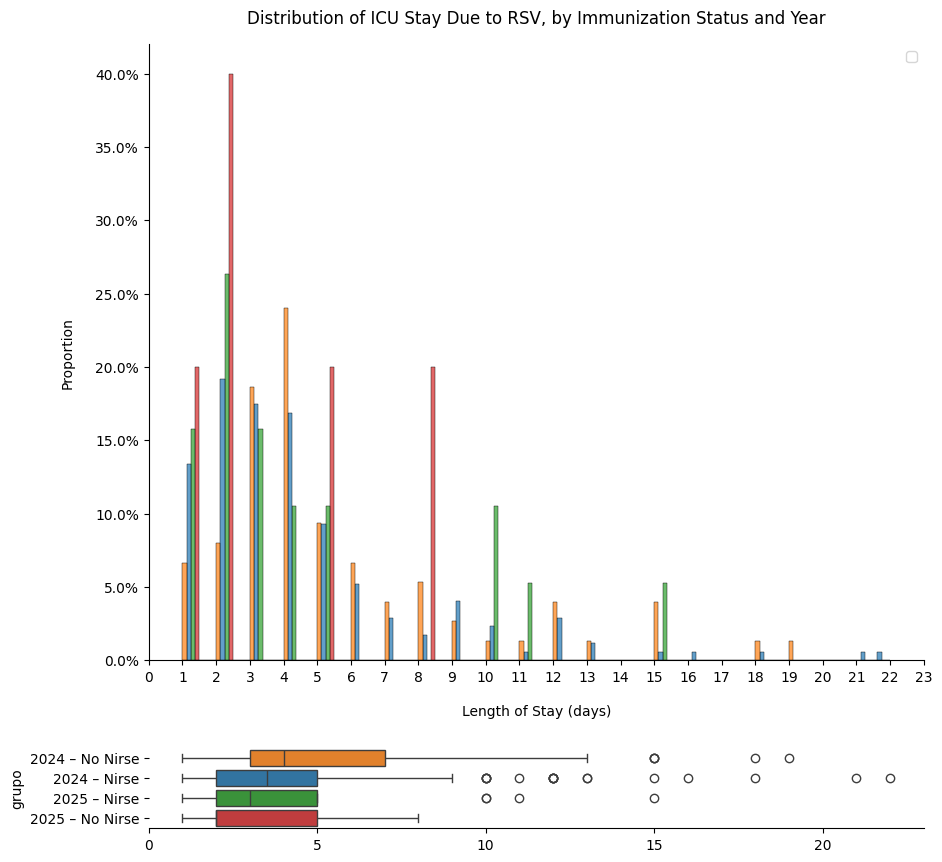

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator

# Copia del DataFrame filtrado
df = (df_f_vrs
      .assign(ola_enfermedad=lambda df: ((df.fechaIng_any.dt.month.between(4, 9)) & (df.fechaIng_any.dt.year==2024)) | ((df.fechaIng_any.dt.month.between(3, 9)) & (df.fechaIng_any.dt.year==2025)),
              ano_ing = lambda df: df.fechaIng_any.dt.year)
      .query('ola_enfermedad')
      [['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado','ano_ing']]
      .copy())
df = df.query('40>=days_upc_vrs>0').copy()

# Crear columna combinada
df['grupo'] = df['ano_ing'].astype(int).astype(str) + "_" + df['inmunizado'].map({1: "Nirse", 0: "NoNirse"})

# Paleta personalizada (puedes ajustarla)
palette = {
    "2024_Nirse": "#1f77b4",
    "2024_NoNirse": "#ff7f0e",
    "2025_Nirse": "#2ca02c",
    "2025_NoNirse": "#d62728"
}

# === FIGURA ===
fig, ax1 = plt.subplots(figsize=(10, 8))

# Histograma
sns.histplot(
    df,
    x="days_upc_vrs",
    hue="grupo",
    multiple="dodge",
    palette=palette,
    common_norm=False,
    alpha=0.7,
    bins=40,
    binwidth=0.5,
    stat="proportion",
    ax=ax1
)

ax1.set_xlabel("Length of Stay (days)", labelpad=15)
ax1.set_ylabel("Proportion", labelpad=15)
ax1.set_xlim(0, df['days_upc_vrs'].max() + 1)
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, axis='x', linestyle='')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.tick_left()

plt.title("Distribution of ICU Stay Due to RSV, by Immunization Status and Year", pad=15)

# Leyenda personalizada
handles, labels = ax1.get_legend_handles_labels()
new_labels = {
    "2024_Nirse": "2024 – Nirse",
    "2024_NoNirse": "2024 – No Nirse",
    "2025_Nirse": "2025 – Nirse",
    "2025_NoNirse": "2025 – No Nirse"
}
ax1.legend(handles=handles, labels=[new_labels[l] for l in labels], title="")

# === BOXPLOT INFERIOR ===
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])

sns.boxplot(
    df,
    x="days_upc_vrs",
    y="grupo",
    palette=palette,
    ax=ax3,
    orient="h"
)

ax3.set_xlim(0, df['days_upc_vrs'].max() + 1)
ax3.set_xlabel("")
ax3.yaxis.set_visible(True)
ax3.set_yticklabels([new_labels[g] for g in df['grupo'].unique()])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Guardar y mostrar
plt.savefig(path_data / 'Figure_S6_p2_by_year.pdf', format='pdf', dpi=400, bbox_inches='tight')
plt.show()

In [12]:
df_f_vrs.query('season_ano==2024').fecha_nac.dt.month.value_counts().sort_index()

fecha_nac
1     13002
2     11866
3     12626
4     12403
5     12112
6     11352
7     11662
8     11468
9     11192
10    12553
11    11964
12    12213
Name: count, dtype: int64

11


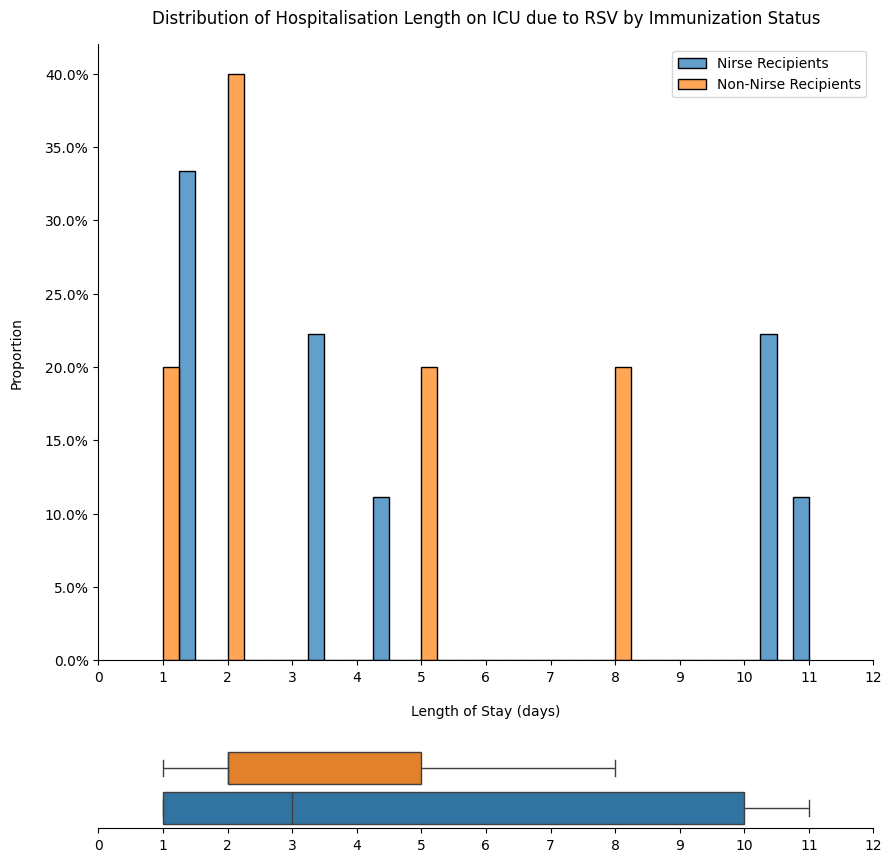

In [16]:
df = (df_f_vrs
      .query('ola_enfermedad')
      .query('season_ano==2025')
      [['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado','ano_ing']])


fig, ax1 = plt.subplots(figsize=(10, 8))

data = df.copy().query('40>=days_upc_vrs>0')

# palette_inverted = [sns.color_palette("Set2")[1], sns.color_palette("Set2")[0]]
#palette_inverted = [sns.color_palette("Set2")[1], '#4682b4']

palette_inverted = ['#ff7f0e', '#1f77b4']

# Graficar el histograma en ax1
sns.histplot(data, 
             x="days_upc_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette=palette_inverted, 
             common_norm=False,
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             stat="proportion",  # Convertir las frecuencias en porcentajes
             binwidth=0.5,
             #shrink=0.8, 
             ax=ax1)  # Usar el primer eje para el histograma

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Length of Stay (days)", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Proportion", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribution of Hospitalisation Length on ICU due to RSV by Immunization Status", pad=15)

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Nirse Recipients", "Non-Nirse Recipients"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data, 
            x="days_upc_vrs", 
            y="inmunizado", 
            palette=palette_inverted, 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = data['days_upc_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Nirse Recipients", "Non-Nirse Recipients"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

plt.savefig(path_data / 'Figure_S6_p2.pdf', format='pdf', dpi=400, bbox_inches='tight')
plt.show()


### kde 

22.0


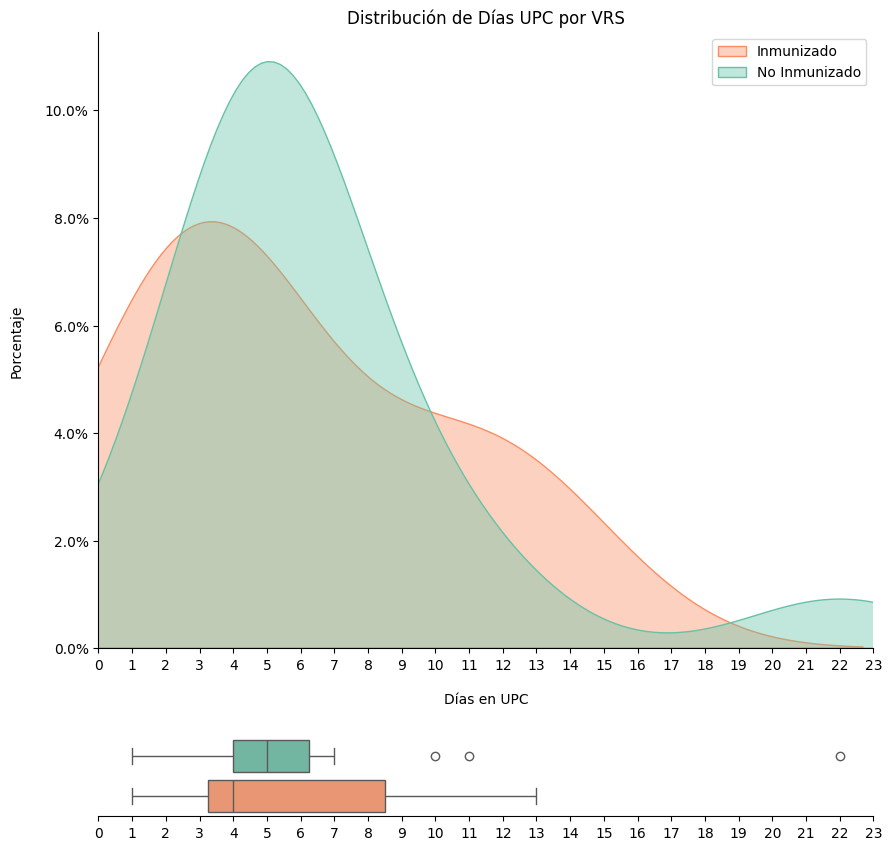

In [9]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

sns.kdeplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax1)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días en UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días UPC por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_upc_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

## Días hospitalización

### histograma

In [10]:
df.copy().query('35<days_estad_vrs')

,RUN,days_estad_vrs,days_upc_vrs,inmunizado
16989,22d892547f28bea1050ad2631275407a6bd2b2e2a7f7ae...,85.0,85,0
50088,80664c6f964bc826571f7b7851a7267310cc8c47d26e43...,44.0,44,0
33663,be4b01bf4d9aa6384d1f058ee8287fb9c3adfbc0adb9fb...,46.0,10,1
11129,853945f2896309af07eeb35c4090a2cf2ebde6606e41a8...,39.0,22,1
113593,4cd1001b33a403c1fe50ddc9031849d961e0ce5523acd5...,37.0,9,1


In [35]:
df = (df_f_vrs
      .query('ola_enfermedad')
      .query('season_ano==2024'))

df.fechaIng_any.dt.month.value_counts()

fechaIng_any
8    1656
9    1553
7    1226
4    1177
5    1142
6    1004
3     495
Name: count, dtype: int64

In [36]:
df.fecha_nac.dt.month.value_counts()

fecha_nac
4     987
5     929
3     924
6     804
2     754
7     739
1     683
12    608
10    585
11    542
8     475
9     223
Name: count, dtype: int64

In [101]:
df.season_ing.value_counts()

AttributeError: 'DataFrame' object has no attribute 'season_ing'

In [111]:
df_safe = df.copy()

17.0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


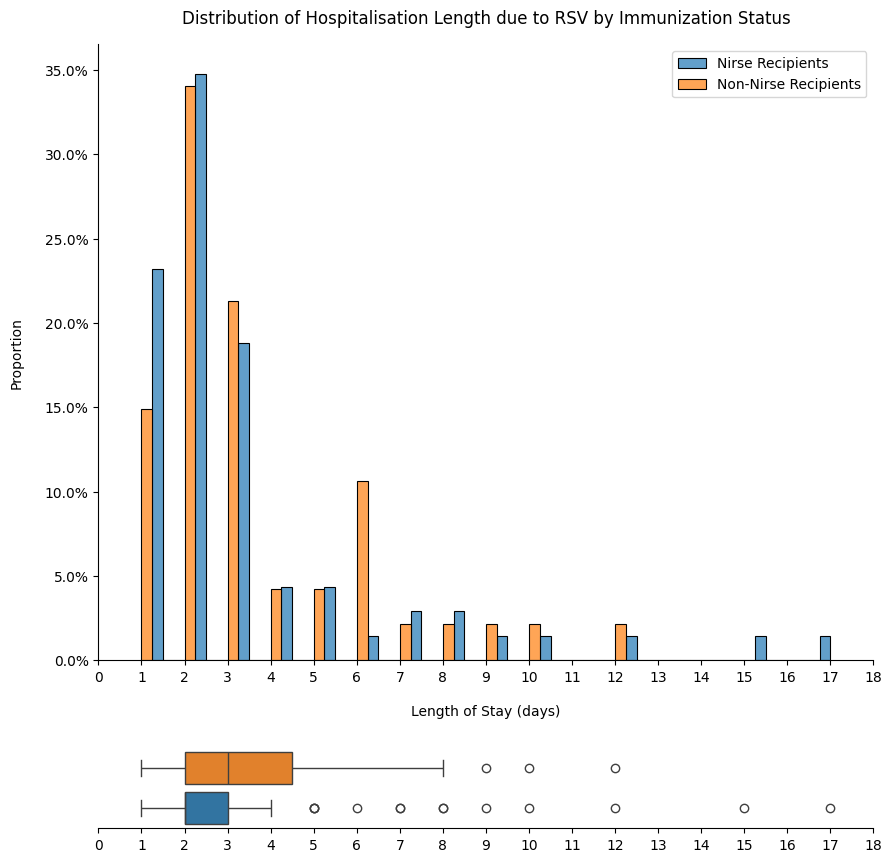

In [113]:
# Crear la figura y el eje

df = (df_safe #df_f_vrs
      #.query('ola_enfermedad')
      .query('season_ing==2025')
      [['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado']])


fig, ax1 = plt.subplots(figsize=(10, 8))

data = df.copy().query('35>=days_estad_vrs>0')

#palette_inverted = [sns.color_palette("Set2")[1], sns.color_palette("Set2")[0]]
palette_inverted = ['#ff7f0e', '#1f77b4']

# Naranja: #ffa500
# Azul: #4682b4

# catch_color = '#1f77b4'    # Azul
# seasonal_color = '#ff7f0e' #naranja

# Graficar el histograma en ax1
sns.histplot(data, 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette=palette_inverted, 
             common_norm=False,
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             stat="proportion",  # Convertir las frecuencias en porcentajes
             binwidth=0.5,
             #shrink=0.8, 
             ax=ax1)  # Usar el primer eje para el histograma

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Length of Stay (days)", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Proportion", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribution of Hospitalisation Length due to RSV by Immunization Status", pad=15)

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Nirse Recipients", "Non-Nirse Recipients"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data, 
            x="days_estad_vrs", 
            y="inmunizado", 
            palette=palette_inverted, 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = data['days_estad_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Nirse Recipients", "Non-nirse Recipients"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

plt.savefig(path_data/'length_hosp_vrs.png', dpi=400, bbox_inches='tight')
plt.savefig(path_data/'length_hosp_vrs.eps', format='eps', bbox_inches='tight')
plt.savefig(path_data / 'Figure_S6_p1.pdf', format='pdf', dpi=400, bbox_inches='tight')
plt.show()

In [28]:
df = (df_f_vrs
      .query('ola_enfermedad')
      .query('season_ano==2025')
      .query('days_estad_vrs>0')
      [['RUN','days_estad_vrs', 'days_upc_vrs','inmunizado','ano_ing']])

df.query('inmunizado==0').days_estad_vrs.median(), df.query('inmunizado==1').days_estad_vrs.median()

(3.0, 2.0)

[] []


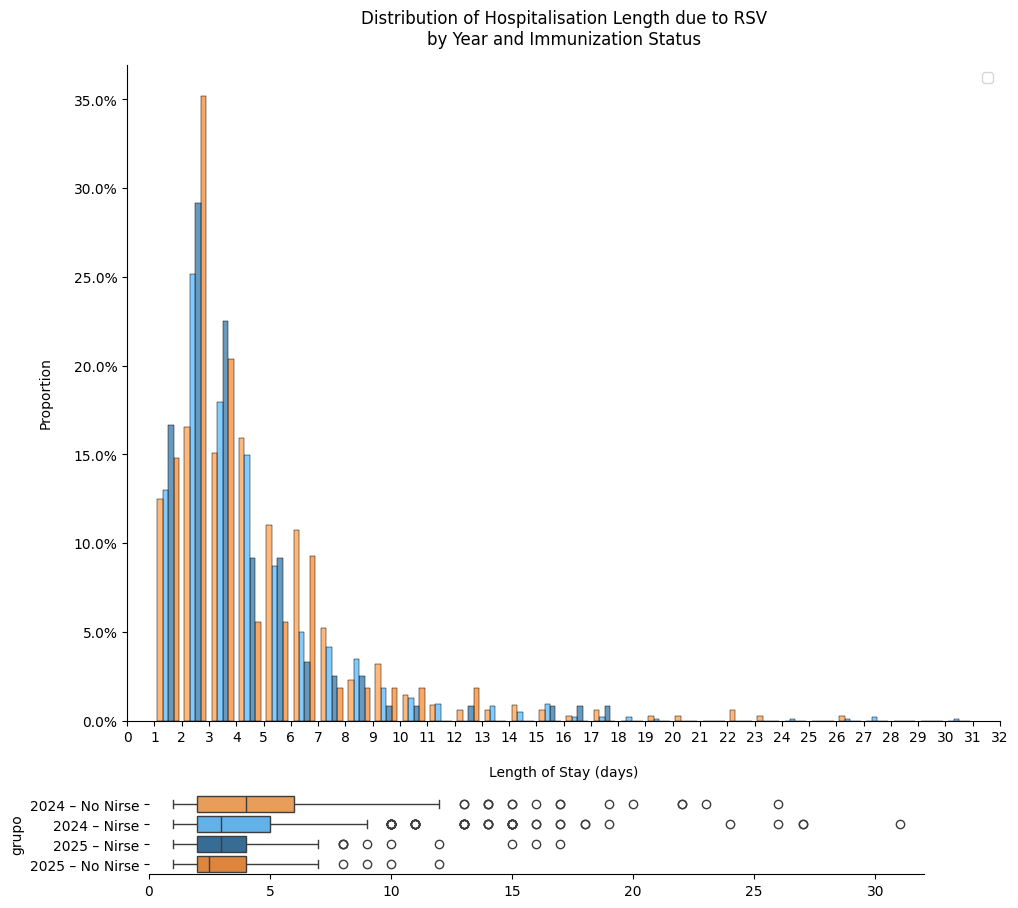

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator


df = (df_f_vrs
      .query('ola_enfermedad'))


# Filtrar y copiar los datos
data = df.copy().query('35 >= days_estad_vrs > 0')[['RUN','days_estad_vrs','inmunizado','ano_ing']].copy()

# Crear nueva variable grupo año + inmunización
data['grupo'] = data['ano_ing'].astype(int).astype(str) + "_" + data['inmunizado'].map({1:"Nirse", 0:"NoNirse"})

# Paleta de colores diferenciada por grupo
palette = {
    "2024_Nirse":    "#4db5ff",
    "2024_NoNirse":  "#ff9b44",
    "2025_Nirse":    "#276ea5",
    "2025_NoNirse":  "#f88221"
}

fig, ax1 = plt.subplots(figsize=(10,8))

# Histograma con barras más anchas (shrink cerca de 1) y con más separación (binwidth mayor)
sns.histplot(
    data,
    x="days_estad_vrs",
    hue="grupo",
    multiple="dodge",
    palette=palette,
    common_norm=False,
    alpha=0.7,
    bins=32,           # uno por cada día
    binwidth=1,        # barras de ancho 1 día
    shrink=0.8,        # 80% del slot dodge → más ancho
    stat="proportion",
    ax=ax1
)

# Etiquetas y formato
ax1.set_xlabel("Length of Stay (days)", labelpad=15)
ax1.set_ylabel("Proportion", labelpad=15)
ax1.set_xlim(0, data['days_estad_vrs'].max()+1)
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, axis='x', linestyle='')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.title("Distribution of Hospitalisation Length due to RSV\nby Year and Immunization Status", pad=15)

# Leyenda
handles, labels = ax1.get_legend_handles_labels()

label_dict = {
    "2024_Nirse":   "2024 – Nirse",
    "2024_NoNirse": "2024 – No Nirse",
    "2025_Nirse":   "2025 – Nirse",
    "2025_NoNirse": "2025 – No Nirse"
}
ax1.legend(handles, [label_dict[l] for l in labels], title="", loc="upper right")

print(handles,labels)


# Boxplot debajo
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])
sns.boxplot(
    data=data,
    x="days_estad_vrs",
    y="grupo",
    palette=palette,
    ax=ax3,
    orient="h"
)
ax3.set_xlim(0, data['days_estad_vrs'].max()+1)
ax3.set_xlabel("")
ax3.set_yticklabels([label_dict[g] for g in data['grupo'].unique()])
ax3.yaxis.set_visible(True)
ax3.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig(path_data/'length_hosp_vrs_widebars.pdf', dpi=400, bbox_inches='tight')
plt.show()



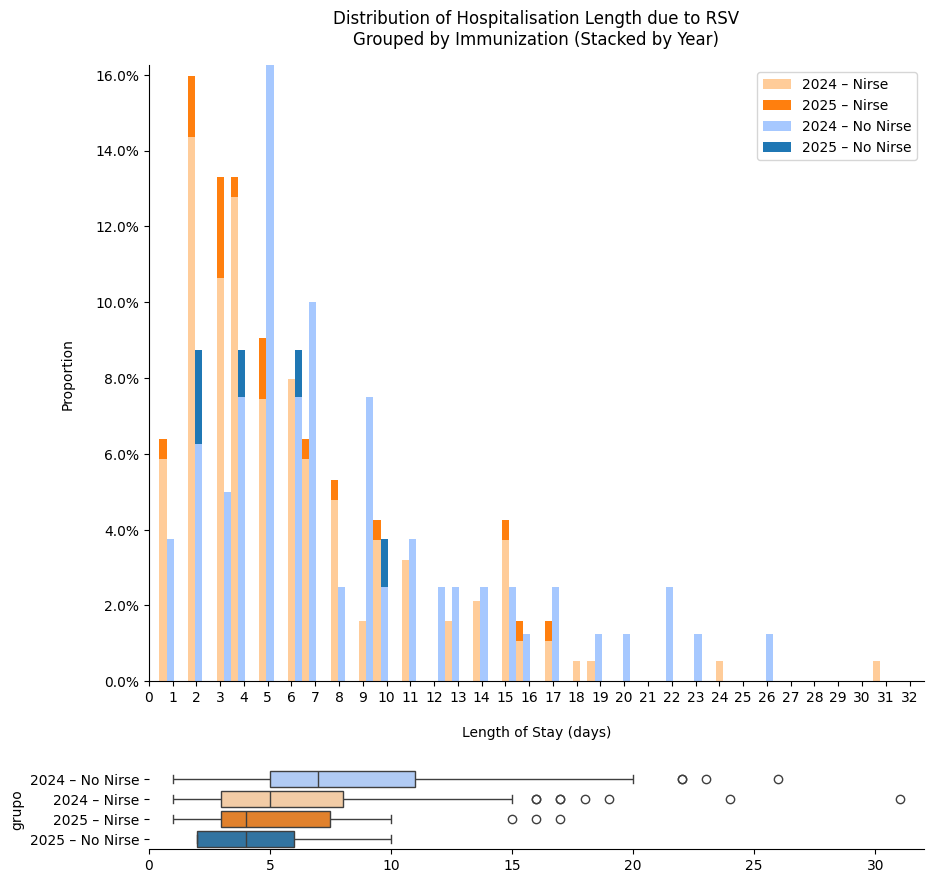

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator
import pandas as pd
import numpy as np

# Filtrar datos
data = df.copy().query('35 >= days_estad_vrs > 0')[['RUN', 'days_estad_vrs', 'inmunizado', 'ano_ing']].copy()
data['inmunizado_str'] = data['inmunizado'].map({1: 'Nirse', 0: 'No Nirse'})
data['grupo'] = data['inmunizado_str'] + "_" + data['ano_ing'].astype(int).astype(str)

# Paleta de colores apilados
colores_apilados = {
    'Nirse_2024': '#ffcc99',      # Naranja claro
    'Nirse_2025': '#ff7f0e',      # Naranja fuerte
    'No Nirse_2024': '#a6c8ff',   # Azul claro
    'No Nirse_2025': '#1f77b4',   # Azul fuerte
}

# Asignar bin a cada observación
binwidth = 0.6
data['bin'] = (data['days_estad_vrs'] // binwidth) * binwidth
data['bin'] = data['bin'].round(1)

# Total por grupo superior para proporciones
total_por_grupo = data.groupby('inmunizado_str').size()

# Tabla de conteo por bin y grupo (año + inmunización)
conteos = data.groupby(['bin', 'grupo']).size().unstack(fill_value=0)

# Separar por grupos superiores (Nirse y No Nirse)
cols_nirse    = [c for c in conteos.columns if c.startswith('Nirse')]
cols_nonirse = [c for c in conteos.columns if c.startswith('No Nirse')]

# Calcular proporciones sobre total de cada grupo superior
props_nirse    = conteos[cols_nirse].divide(total_por_grupo['Nirse'])
props_nonirse = conteos[cols_nonirse].divide(total_por_grupo['No Nirse'])

# Parámetros de las barras
bar_width = 0.3   # Barren más delgadas
offset    = 0.3  # Separación horizontal entre grupos

# Iniciar gráfico
fig, ax1 = plt.subplots(figsize=(10, 8))

bottom_nirse    = np.zeros(len(props_nirse))
bottom_nonirse = np.zeros(len(props_nonirse))
bins            = props_nirse.index

# Dibujar barras apiladas para cada bin
for col in cols_nirse:
    ax1.bar(bins,
            props_nirse[col],
            bottom=bottom_nirse,
            width=bar_width,
            color=colores_apilados[col],
            label=col)
    bottom_nirse += props_nirse[col]

for col in cols_nonirse:
    ax1.bar(bins + offset,
            props_nonirse[col],
            bottom=bottom_nonirse,
            width=bar_width,
            color=colores_apilados[col],
            label=col)
    bottom_nonirse += props_nonirse[col]

# Configuración de ejes y título
ax1.set_xlabel("Length of Stay (days)", labelpad=15)
ax1.set_ylabel("Proportion", labelpad=15)
ax1.set_xlim(0, data['bin'].max() + 2)
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, axis='x', linestyle='')
ax1.spines[['top','right']].set_visible(False)
ax1.yaxis.tick_left()
plt.title("Distribution of Hospitalisation Length due to RSV\nGrouped by Immunization (Stacked by Year)", pad=15)

# Leyenda personalizada
legend_labels = {
    'Nirse_2024':     '2024 – Nirse',
    'Nirse_2025':     '2025 – Nirse',
    'No Nirse_2024': '2024 – No Nirse',
    'No Nirse_2025': '2025 – No Nirse'
}
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, [legend_labels[l] for l in labels], title="", loc='upper right')

# Agregar boxplot debajo
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])
sns.boxplot(data=data,
            x="days_estad_vrs",
            y="grupo",
            palette=colores_apilados,
            ax=ax3,
            orient="h")
ax3.set_xlim(0, data['days_estad_vrs'].max() + 1)
ax3.set_xlabel("")
ax3.set_yticklabels([legend_labels[g] for g in data['grupo'].unique()])
ax3.spines[['top','right','left']].set_visible(False)

# Guardar
plt.savefig(path_data/'length_hosp_vrs_stacked_thinbars.pdf', format='pdf', dpi=400, bbox_inches='tight')
plt.savefig(path_data/'length_hosp_vrs_stacked_thinbars.png', dpi=400, bbox_inches='tight')
plt.show()




In [18]:
from scipy.stats import mannwhitneyu
def calculate_median_pval(recipients_data,non_recipients_data):
    
    stat, p_value = mannwhitneyu(recipients_data, non_recipients_data, alternative='two-sided') #recipients != non_recipients p_value
    
    return p_value

In [24]:
calculate_median_pval(data.query('inmunizado==1').query('days_estad_vrs>0')['days_estad_vrs'],data.query('inmunizado==0').query('days_estad_vrs>0')['days_estad_vrs'])

6.227286439943271e-06

In [ ]:
data = df.query('days_estad_vrs>0')
calculate_median_pval(data.query('inmunizado==1')['days_estad_vrs'],data.query('inmunizado==0')['days_estad_vrs'])

5.848260273557908e-06

In [33]:
df.to_csv(path_data/'df_ignasi.csv', index=False)

In [30]:
data = df.query('days_upc_vrs>0')
calculate_median_pval(data.query('inmunizado==1')['days_upc_vrs'],data.query('inmunizado==0')['days_upc_vrs'])

0.006236286071783177

In [ ]:
5.848260273557908e-06 <0.00001

True

In [ ]:
calculate_median_pval(data.query('inmunizado==1').query('days_estad_vrs>0')['days_estad_vrs'],data.query('inmunizado==0').query('days_estad_vrs>0')['days_estad_vrs'])

In [19]:
df.query('days_estad_vrs>0').groupby(['inmunizado']).days_estad_vrs.mean()

inmunizado
0    5.253205
1    4.188636
Name: days_estad_vrs, dtype: float64

In [5]:
df.query('days_estad_vrs>0').groupby(['inmunizado']).days_estad_vrs.median()


inmunizado
0    4.0
1    3.0
Name: days_estad_vrs, dtype: float64

In [46]:
df.query('days_upc_vrs>0').groupby(['inmunizado']).days_upc_vrs.mean()

inmunizado
0    6.987342
1    4.585635
Name: days_upc_vrs, dtype: float64

In [6]:
df.query('days_upc_vrs>0').groupby(['inmunizado']).days_upc_vrs.median()

inmunizado
0    4.0
1    4.0
Name: days_upc_vrs, dtype: float64

In [20]:
quartiles = df[df['days_estad_vrs'] > 0].groupby('inmunizado')['days_estad_vrs'].describe(percentiles=[0.25, 0.5, 0.75])
print(quartiles)

            count      mean       std  min  25%  50%  75%   max
inmunizado                                                     
0           312.0  5.253205  6.346125  1.0  2.0  4.0  6.0  85.0
1           880.0  4.188636  4.177338  1.0  2.0  3.0  5.0  46.0


In [21]:
quartiles = df[df['days_upc_vrs'] > 0].groupby('inmunizado')['days_upc_vrs'].describe(percentiles=[0.25, 0.5, 0.75])
print(quartiles)

            count      mean        std  min  25%  50%  75%   max
inmunizado                                                      
0            79.0  6.987342  10.618674  1.0  3.0  4.0  7.0  85.0
1           181.0  4.585635   3.771179  1.0  2.0  4.0  5.0  22.0


In [ ]:
inmunes = df['days_estad_vrs'][(df['inmunizado']==1) & (df['days_estad_vrs']>0)]
no_inmunes = df['days_estad_vrs'][(df['inmunizado']==0) & (df['days_estad_vrs']>0)]

media_inmunes = inmunes.mean()
media_no_inmunes = no_inmunes.mean()
n_inmunes = inmunes.count()
n_no_inmunes = no_inmunes.count()

t_stat, p_value = stats.ttest_ind(inmunes, no_inmunes)

print(f"Media (Inmunizados): {media_inmunes:.2f} (N = {n_inmunes})")
print(f"Media (No inmunizados): {media_no_inmunes:.2f} (N = {n_no_inmunes})")

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

Media (Inmunizados): 4.19 (N = 880)
Media (No inmunizados): 5.25 (N = 312)
Estadístico t: -3.3389
Valor p: 0.0009
Existe una diferencia significativa entre las medias de los dos grupos.


In [51]:
# Filtrar los datos
inmunes = df['days_upc_vrs'][(df['inmunizado'] == 1) & (df['days_upc_vrs'] > 0)]
no_inmunes = df['days_upc_vrs'][(df['inmunizado'] == 0) & (df['days_upc_vrs'] > 0)]

media_inmunes = inmunes.mean()
media_no_inmunes = no_inmunes.mean()
n_inmunes = inmunes.count()
n_no_inmunes = no_inmunes.count()

t_stat, p_value = stats.ttest_ind(inmunes, no_inmunes)

print(f"Media (Inmunizados): {media_inmunes:.2f} (N = {n_inmunes})")
print(f"Media (No inmunizados): {media_no_inmunes:.2f} (N = {n_no_inmunes})")

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")
    
if t_stat < 0:
    p_value_one_tail = p_value / 2
else:
    p_value_one_tail = 1

print(f'Valor p (una cola): {p_value_one_tail:.4f}')

Media (Inmunizados): 4.59 (N = 181)
Media (No inmunizados): 6.99 (N = 79)
Estadístico t: -2.6848
Valor p: 0.0077
Existe una diferencia significativa entre las medias de los dos grupos.
Valor p (una cola): 0.0039


### kde

C:\Users\ntrig\AppData\Local\Temp\ipykernel_28356\3757958103.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['days_estad_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_28356\3757958103.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


27.0


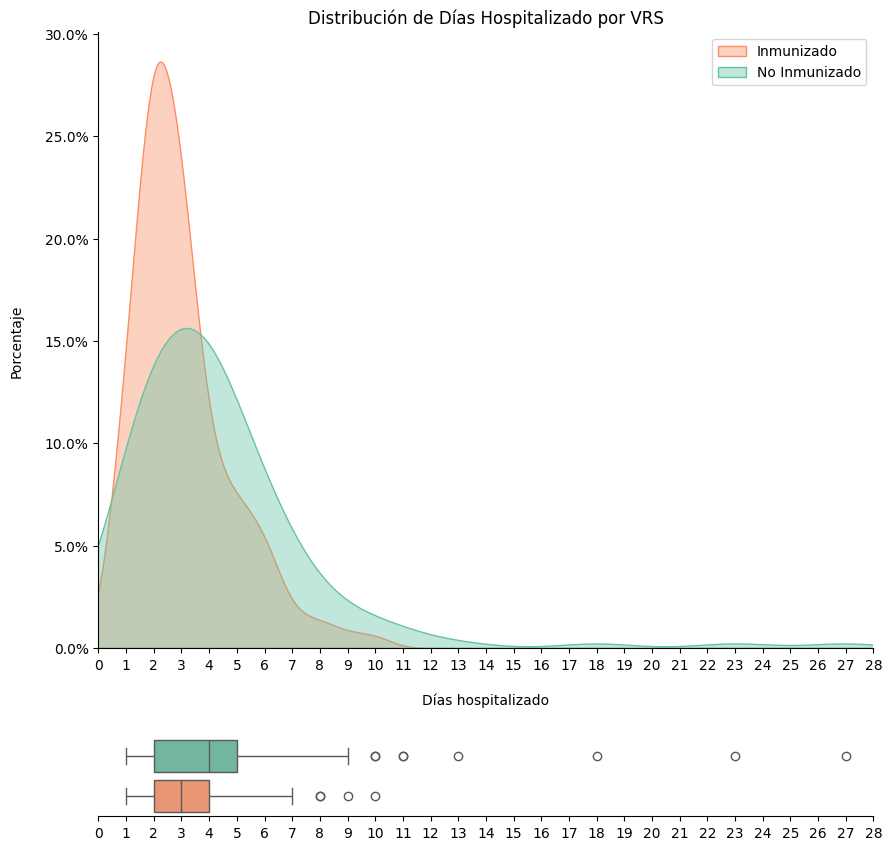

In [137]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

sns.kdeplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax1)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

## GRAFICOS NIRSE

In [4]:
path_actual = Path.cwd()
path_data = path_actual.parent/'Data' 
path_nirsecl = path_actual.parent.parent/'Nirse_cl' / 'Data'
df_historic = pd.read_csv(path_nirsecl/"data_sintrib.csv").drop(columns=['Unnamed: 0'])

In [66]:
import pickle
with open(path_data/'lista_ruts_cardio.pkl', 'rb') as f:
    lista_ruts_cardio = pickle.load(f)

with open(path_data/'lista_ruts_preterms.pkl', 'rb') as f:
    lista_ruts_preterms = pickle.load(f)
    
lista_risky = np.union1d(lista_ruts_cardio, lista_ruts_preterms)

In [ ]:
################ CARDIO 
path_nirsecl = path_actual.parent.parent/'Nirse_cl' / 'Data'

df_historic = (
    pd.read_csv(path_nirsecl/"data_sintrib.csv") #  data_sintrib data
    .drop(columns=['Unnamed: 0'])
   # .query('RUN.isin(@lista_ruts_cardio)')
)

def agregate_week(df, year, week):
    new_row = {'year': year, 'epiweekupc': week, 'hospitalizado': 0, 'hospitalizado_acumulado': df['hospitalizado_acumulado'].max()}
    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df_historic[['RUN', 'FECHA_NAC', 'fechaIng', 'epiweek', 'year','season', 'elegibilidad', 'cama', 'ingreso_UPC','critico', 'epiweekupc']]
df_nirse = df_historic.assign(is_elegible = lambda x: x.year == x.elegibilidad,
                              hospitalizado = lambda x: np.where(x['fechaIng'].notna(), 1, 0)).query('epiweek<=40')

semanas = np.arange(df_nirse.epiweek.min(),df_nirse.epiweek.max()) ### aca puedo cambiar a las semanas que quiera
anios = df_nirse['year'].unique()

df_semanas_completas = (
    pd.MultiIndex.from_product([anios, semanas], names=['year', 'epiweek'])
    .to_frame(index=False)
)

df_elig = df_nirse[df_nirse['is_elegible'] == True]
df_no_elig = df_nirse[df_nirse['is_elegible'] == False]

df_elig_agg = (
    df_semanas_completas.merge(
        df_elig.groupby(['year', 'epiweek'])['hospitalizado']
        .sum()
        .reset_index(), on=['year', 'epiweek'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
    )

df_no_elig_agg = (
    df_semanas_completas.merge(
        df_no_elig.groupby(['year', 'epiweek'])['hospitalizado']
        .sum()
        .reset_index(), on=['year', 'epiweek'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
    )

years_line = [2019, 2022, 2023] #, 2024
year_hist = 2024

df_elig_line = df_elig_agg[df_elig_agg['year'].isin(years_line)]
df_elig_hist = df_elig_agg[df_elig_agg['year'] == year_hist]

fig, ax = plt.subplots(figsize=(10,6))

# Graficar las líneas
for y in years_line:
    data_y = df_elig_line[df_elig_line['year'] == y]
    ax.plot(data_y['epiweek'], data_y['hospitalizado_acumulado'], label=str(y))
    

data_2024 = df_elig_hist
ax.bar(data_2024['epiweek'], data_2024['hospitalizado_acumulado'], 
       alpha=0.5, label='2024 ')

ax.set_xlabel('Epiweek',fontsize=18)
ax.set_ylabel('Cumulative Hospitalisations',fontsize=18)
ax.set_title('Cumulative Weekly RSV Hospitalisations (Eligible Population)',fontsize=19)
ax.legend(fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.grid(True)
plt.tight_layout()
plt.savefig(path_data/'eleg_vrs.png', dpi=400)
plt.savefig(path_data/'eleg_vrs.eps', format='eps')
plt.show()


fig, ax = plt.subplots(figsize=(10,6))

# Líneas para 2019, 2022, 2023
df_no_elig_line = df_no_elig_agg[df_no_elig_agg['year'].isin(years_line)]
df_no_elig_hist = df_no_elig_agg[df_no_elig_agg['year'] == year_hist]

for y in years_line:
    data_y = df_no_elig_line[df_no_elig_line['year'] == y]
    ax.plot(data_y['epiweek'], data_y['hospitalizado_acumulado'], label=str(y))
    
# Histograma para 2024
data_2024_no_elig = df_no_elig_hist
ax.bar(data_2024_no_elig['epiweek'], data_2024_no_elig['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek',fontsize=18)
ax.set_ylabel('Cumulative Hospitalisations',fontsize=18)
ax.set_title('Cumulative Weekly RSV Hospitalisations (Non-Eligible Population)',fontsize=19)
#ax.legend()
ax.tick_params(axis='both', which='major', labelsize=17)
ax.grid(True)
plt.tight_layout()
plt.savefig(path_data/'non_eleg_vrs.png', dpi=400)
plt.savefig(path_data/'non_eleg_vrs.eps', format='eps')
plt.show()


def agregate_week(df, year, week):
    new_row = {'year': year, 'epiweekupc': week, 'hospitalizado': 0, 'hospitalizado_acumulado': df['hospitalizado_acumulado'].max()}
    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df_nirse_upc = df_historic.assign(is_elegible = lambda x: x.year == x.elegibilidad,
                              hospitalizado = lambda x: x['critico']==1).query('epiweekupc<=40')

semanas = np.arange(1,40) ### aca puedo cambiar a las semanas que quiera df_nirse_upc.epiweekupc.min(),df_nirse_upc.epiweekupc.max()
anios = df_nirse_upc['year'].unique()

df_semanas_completas = (
    pd.MultiIndex.from_product([anios, semanas], names=['year', 'epiweekupc'])
    .to_frame(index=False)
)

df_elig = df_nirse_upc[df_nirse_upc['is_elegible'] == True]
df_no_elig = df_nirse_upc[df_nirse_upc['is_elegible'] == False]

df_elig_agg = (
    df_semanas_completas.merge(
        df_elig.groupby(['year', 'epiweekupc'])['hospitalizado']
        .sum()
        .reset_index(), on=['year', 'epiweekupc'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
    )

df_no_elig_agg = (
    df_semanas_completas.merge(
        df_no_elig.groupby(['year', 'epiweekupc'])['hospitalizado']
        .sum()
        .reset_index(), on=['year', 'epiweekupc'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
    )

years_line = [2019, 2022, 2023] #, 2024
year_hist = 2024

df_elig_line = df_elig_agg[df_elig_agg['year'].isin(years_line)]
df_elig_hist = df_elig_agg[df_elig_agg['year'] == year_hist]

fig, ax = plt.subplots(figsize=(10,6))

# Graficar las líneas
for y in years_line:
    data_y = df_elig_line[df_elig_line['year'] == y]
    
    if data_y.epiweekupc.max() < 40:
        data_y = agregate_week(data_y, y, 40)
    
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))
    

data_2024 = agregate_week(df_elig_hist, 2024, 40) #df_elig_hist
ax.bar(data_2024['epiweekupc'], data_2024['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek', fontsize=18)
ax.set_ylabel('Cumulative Hospitalisations', fontsize=18)
ax.set_title('Cumulative Weekly RSV-ICU Hospitalisations (Eligible Population)', fontsize=19)
#ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.grid(True)
plt.tight_layout()
plt.savefig(path_data/'eleg_upc.png', dpi=400)
plt.savefig(path_data/'eleg_upc.eps', format='eps')
plt.show()



fig, ax = plt.subplots(figsize=(10,6))

# Líneas para 2019, 2022, 2023
df_no_elig_line = df_no_elig_agg[df_no_elig_agg['year'].isin(years_line)]
df_no_elig_hist = df_no_elig_agg[df_no_elig_agg['year'] == year_hist]

for y in years_line:
    data_y = df_no_elig_line[df_no_elig_line['year'] == y]
    
    if data_y.epiweekupc.max() < 40:
        data_y = agregate_week(data_y, y, 40)
    
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))

# Histograma para 2024
data_2024_no_elig = agregate_week(df_no_elig_hist, 2024, 40) #df_no_elig_hist
ax.bar(data_2024_no_elig['epiweekupc'], data_2024_no_elig['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek', fontsize=18)
ax.set_ylabel('Cumulative Hospitalisations', fontsize=18)
ax.set_title('Cumulative Weekly RSV-ICU Hospitalisations (Non-Eligible Population)', fontsize=19)
#ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.grid(True)
plt.tight_layout()
plt.savefig(path_data/'no_eleg_upc.png', dpi=400)
plt.savefig(path_data/'no_eleg_upc.eps', format='eps')
plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


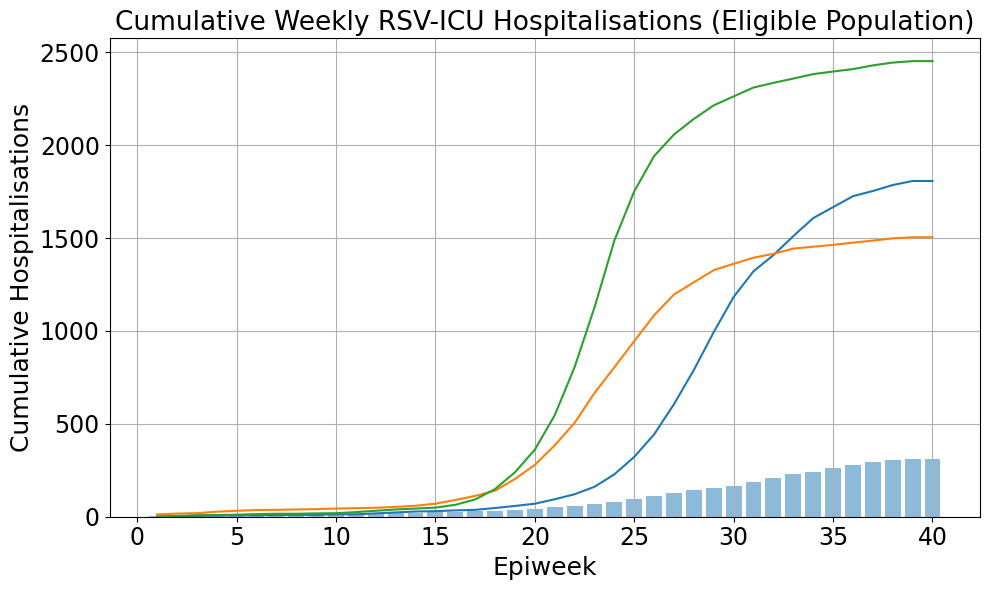

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


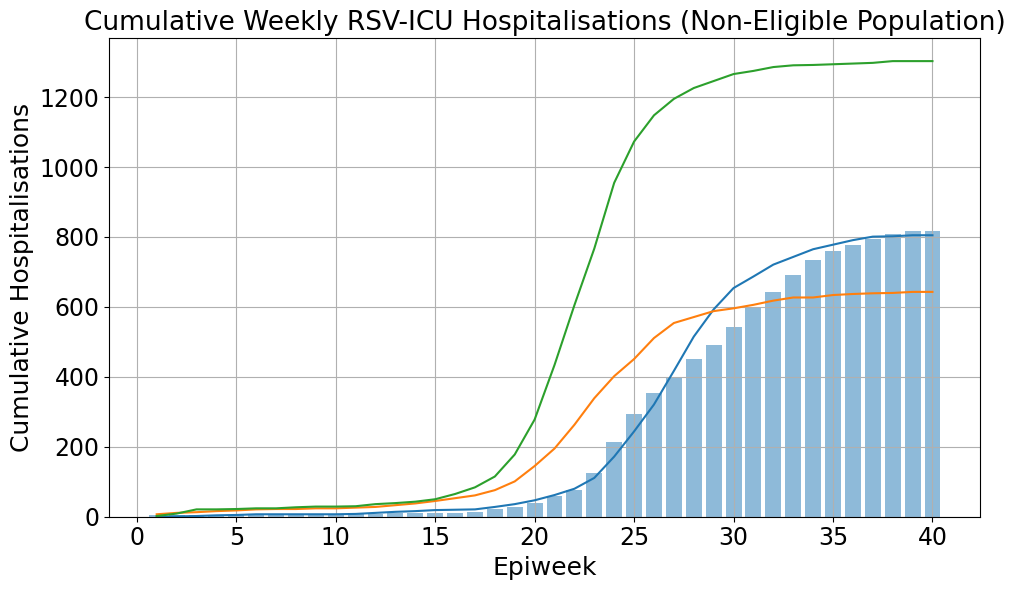

In [6]:
def agregate_week(df, year, week):
    new_row = {'year': year, 'epiweekupc': week, 'hospitalizado': 0, 'hospitalizado_acumulado': df['hospitalizado_acumulado'].max()}
    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df_nirse_upc = df_historic.assign(is_elegible = lambda x: x.year == x.elegibilidad,
                              hospitalizado = lambda x: x['critico']==1).query('epiweekupc<=40')

semanas = np.arange(1,40) ### aca puedo cambiar a las semanas que quiera df_nirse_upc.epiweekupc.min(),df_nirse_upc.epiweekupc.max()
anios = df_nirse_upc['year'].unique()

df_semanas_completas = (
    pd.MultiIndex.from_product([anios, semanas], names=['year', 'epiweekupc'])
    .to_frame(index=False)
)

df_elig = df_nirse_upc[df_nirse_upc['is_elegible'] == True]
df_no_elig = df_nirse_upc[df_nirse_upc['is_elegible'] == False]

df_elig_agg = (
    df_semanas_completas.merge(
        df_elig.groupby(['year', 'epiweekupc'])['hospitalizado']
        .sum()
        .reset_index(), on=['year', 'epiweekupc'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
    )

df_no_elig_agg = (
    df_semanas_completas.merge(
        df_no_elig.groupby(['year', 'epiweekupc'])['hospitalizado']
        .sum()
        .reset_index(), on=['year', 'epiweekupc'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
    )

years_line = [2019, 2022, 2023] #, 2024
year_hist = 2024

df_elig_line = df_elig_agg[df_elig_agg['year'].isin(years_line)]
df_elig_hist = df_elig_agg[df_elig_agg['year'] == year_hist]

fig, ax = plt.subplots(figsize=(10,6))

# Graficar las líneas
for y in years_line:
    data_y = df_elig_line[df_elig_line['year'] == y]
    
    if data_y.epiweekupc.max() < 40:
        data_y = agregate_week(data_y, y, 40)
    
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))
    

data_2024 = agregate_week(df_elig_hist, 2024, 40) #df_elig_hist
ax.bar(data_2024['epiweekupc'], data_2024['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek', fontsize=18)
ax.set_ylabel('Cumulative Hospitalisations', fontsize=18)
ax.set_title('Cumulative Weekly RSV-ICU Hospitalisations (Eligible Population)', fontsize=19)
#ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.grid(True)
plt.tight_layout()
plt.savefig(path_data/'eleg_upc.png', dpi=400)
plt.savefig(path_data/'eleg_upc.eps', format='eps')
plt.show()



fig, ax = plt.subplots(figsize=(10,6))

# Líneas para 2019, 2022, 2023
df_no_elig_line = df_no_elig_agg[df_no_elig_agg['year'].isin(years_line)]
df_no_elig_hist = df_no_elig_agg[df_no_elig_agg['year'] == year_hist]

for y in years_line:
    data_y = df_no_elig_line[df_no_elig_line['year'] == y]
    
    if data_y.epiweekupc.max() < 40:
        data_y = agregate_week(data_y, y, 40)
    
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))

# Histograma para 2024
data_2024_no_elig = agregate_week(df_no_elig_hist, 2024, 40) #df_no_elig_hist
ax.bar(data_2024_no_elig['epiweekupc'], data_2024_no_elig['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek', fontsize=18)
ax.set_ylabel('Cumulative Hospitalisations', fontsize=18)
ax.set_title('Cumulative Weekly RSV-ICU Hospitalisations (Non-Eligible Population)', fontsize=19)
#ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.grid(True)
plt.tight_layout()
plt.savefig(path_data/'no_eleg_upc.png', dpi=400)
plt.savefig(path_data/'no_eleg_upc.eps', format='eps')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


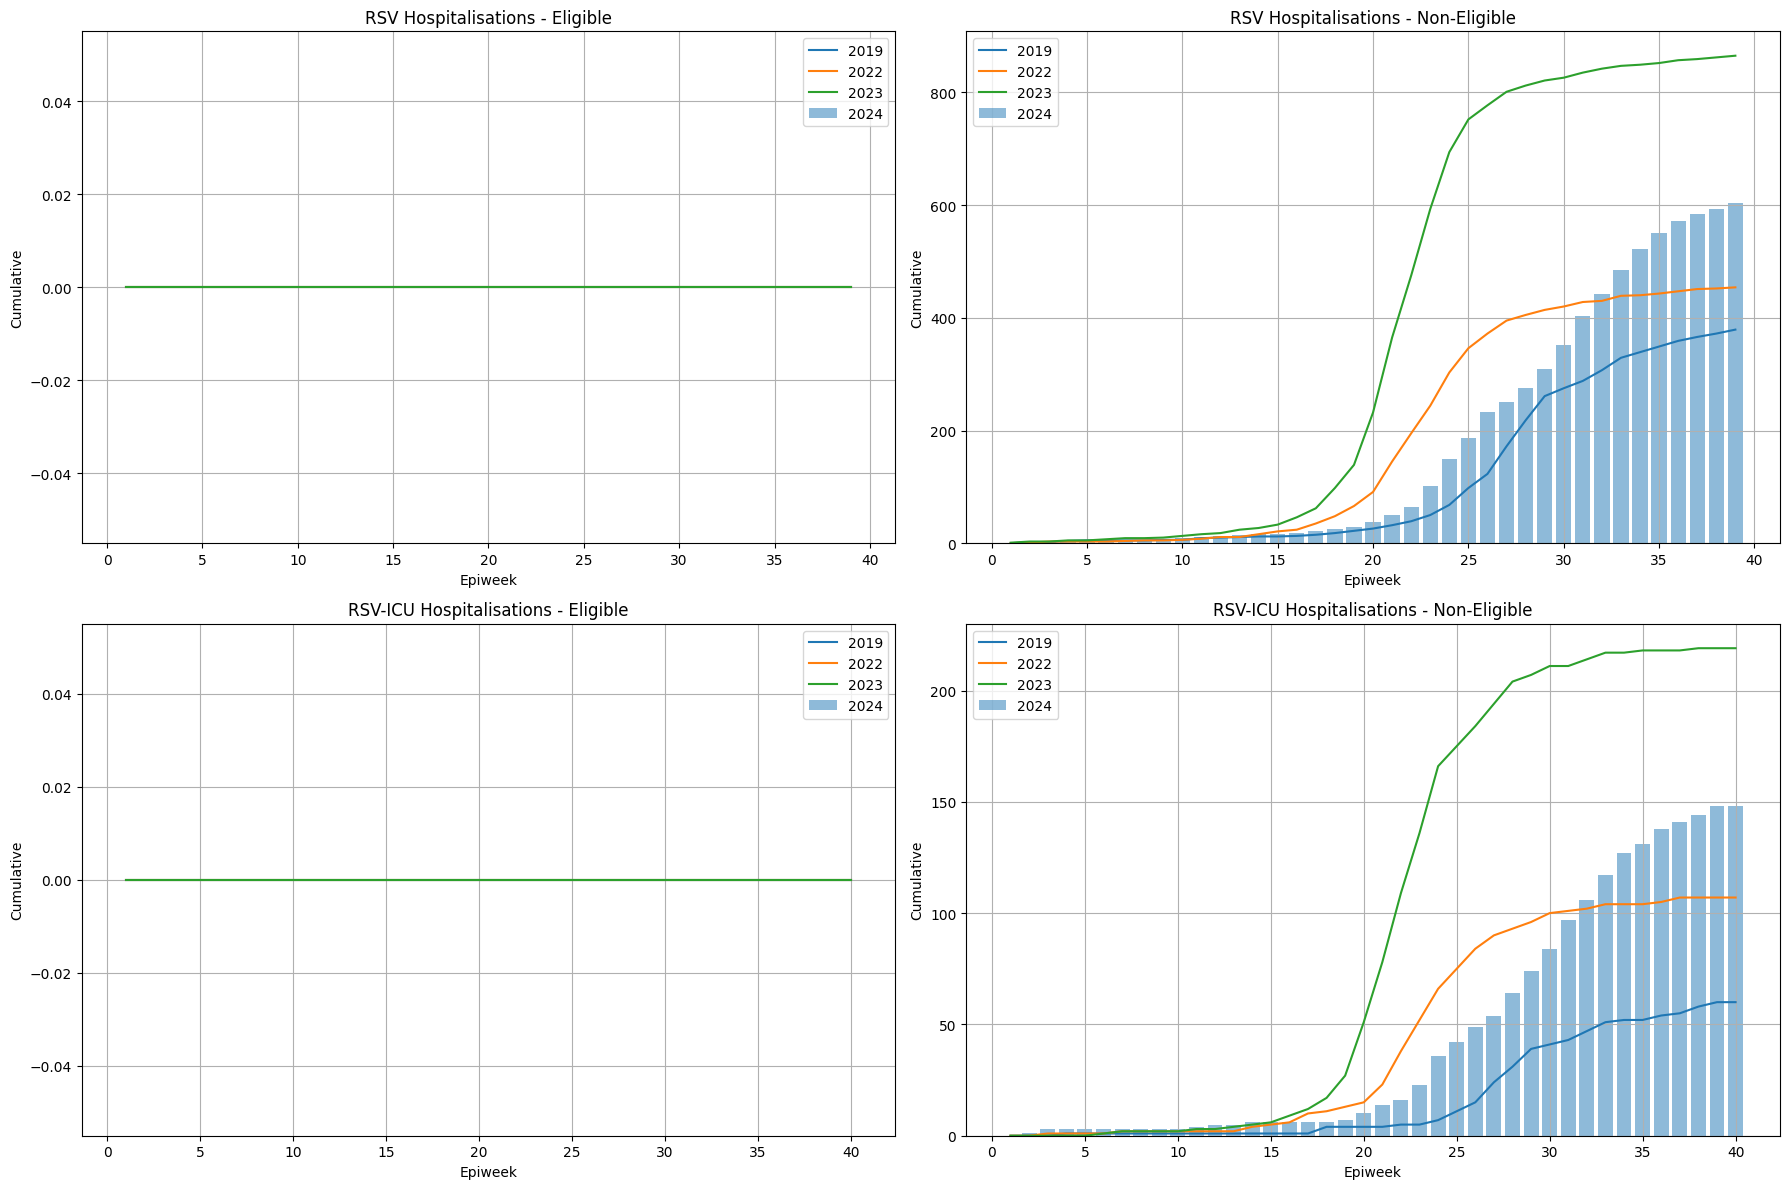

In [5]:
path_nirsecl = path_actual.parent.parent/'Nirse_cl' / 'Data'

import matplotlib.pyplot as plt

# Cargar datos

df_historic = (
    pd.read_csv(path_nirsecl/"data_sintrib.csv")
    .drop(columns=['Unnamed: 0'])
    #.query('age<=12')
  #  .query('RUN.isin(@lista_ruts_preterms)')
)

# Definición auxiliar

def agregate_week(df, year, week):
    new_row = {'year': year, 'epiweekupc': week, 'hospitalizado': 0, 'hospitalizado_acumulado': df['hospitalizado_acumulado'].max()}
    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

# Procesamiento para hospitalizaciones generales
df_nirse = df_historic.assign(
    is_elegible = lambda x: x.year == x.elegibilidad,
    hospitalizado = lambda x: np.where(x['fechaIng'].notna(), 1, 0)
).query('epiweek<=40')

semanas = np.arange(df_nirse.epiweek.min(), df_nirse.epiweek.max())
anios = df_nirse['year'].unique()

df_semanas_completas = (
    pd.MultiIndex.from_product([anios, semanas], names=['year', 'epiweek'])
    .to_frame(index=False)
)

df_elig = df_nirse[df_nirse['is_elegible'] == True]
df_no_elig = df_nirse[df_nirse['is_elegible'] == False]

df_elig_agg = (
    df_semanas_completas.merge(
        df_elig.groupby(['year', 'epiweek'])['hospitalizado'].sum().reset_index(),
        on=['year', 'epiweek'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
)

df_no_elig_agg = (
    df_semanas_completas.merge(
        df_no_elig.groupby(['year', 'epiweek'])['hospitalizado'].sum().reset_index(),
        on=['year', 'epiweek'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
)

# Procesamiento para hospitalizaciones en UPC
df_nirse_upc = df_historic.assign(
    is_elegible = lambda x: x.year == x.elegibilidad,
    hospitalizado = lambda x: x['critico'] == 1
).query('epiweekupc<=40')

semanas_upc = np.arange(1, 40)
anios_upc = df_nirse_upc['year'].unique()

df_semanas_completas_upc = (
    pd.MultiIndex.from_product([anios_upc, semanas_upc], names=['year', 'epiweekupc'])
    .to_frame(index=False)
)

df_elig_upc = df_nirse_upc[df_nirse_upc['is_elegible'] == True]
df_no_elig_upc = df_nirse_upc[df_nirse_upc['is_elegible'] == False]

df_elig_agg_upc = (
    df_semanas_completas_upc.merge(
        df_elig_upc.groupby(['year', 'epiweekupc'])['hospitalizado'].sum().reset_index(),
        on=['year', 'epiweekupc'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
)

df_no_elig_agg_upc = (
    df_semanas_completas_upc.merge(
        df_no_elig_upc.groupby(['year', 'epiweekupc'])['hospitalizado'].sum().reset_index(),
        on=['year', 'epiweekupc'], how='left')
    .assign(hospitalizado = lambda x: x['hospitalizado'].fillna(0),
            hospitalizado_acumulado = lambda x: x.groupby('year')['hospitalizado'].cumsum())
)

# Preparación para gráfico combinado
years_line = [2019, 2022, 2023]
year_hist = 2024

df_elig_line = df_elig_agg[df_elig_agg['year'].isin(years_line)]
df_elig_hist = df_elig_agg[df_elig_agg['year'] == year_hist]

df_no_elig_line = df_no_elig_agg[df_no_elig_agg['year'].isin(years_line)]
df_no_elig_hist = df_no_elig_agg[df_no_elig_agg['year'] == year_hist]

df_elig_line_upc = df_elig_agg_upc[df_elig_agg_upc['year'].isin(years_line)]
df_elig_hist_upc = df_elig_agg_upc[df_elig_agg_upc['year'] == year_hist]

df_no_elig_line_upc = df_no_elig_agg_upc[df_no_elig_agg_upc['year'].isin(years_line)]
df_no_elig_hist_upc = df_no_elig_agg_upc[df_no_elig_agg_upc['year'] == year_hist]

# Crear figura combinada
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
axs = axs.flatten()

# Subplot 1: Hospitalizaciones elegibles
ax = axs[0]
for y in years_line:
    data_y = df_elig_line[df_elig_line['year'] == y]
    ax.plot(data_y['epiweek'], data_y['hospitalizado_acumulado'], label=str(y))
ax.bar(df_elig_hist['epiweek'], df_elig_hist['hospitalizado_acumulado'], alpha=0.5, label='2024')
ax.set_title('RSV Hospitalisations - Eligible')
ax.set_xlabel('Epiweek')
ax.set_ylabel('Cumulative')
ax.grid(True)
ax.legend()

# Subplot 2: Hospitalizaciones no elegibles
ax = axs[1]
for y in years_line:
    data_y = df_no_elig_line[df_no_elig_line['year'] == y]
    ax.plot(data_y['epiweek'], data_y['hospitalizado_acumulado'], label=str(y))
ax.bar(df_no_elig_hist['epiweek'], df_no_elig_hist['hospitalizado_acumulado'], alpha=0.5, label='2024')
ax.set_title('RSV Hospitalisations - Non-Eligible')
ax.set_xlabel('Epiweek')
ax.set_ylabel('Cumulative')
ax.grid(True)
ax.legend()

# Subplot 3: Hospitalizaciones UPC elegibles
ax = axs[2]
for y in years_line:
    data_y = df_elig_line_upc[df_elig_line_upc['year'] == y]
    if data_y.epiweekupc.max() < 40:
        data_y = agregate_week(data_y, y, 40)
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))
data_2024 = agregate_week(df_elig_hist_upc, 2024, 40)
ax.bar(data_2024['epiweekupc'], data_2024['hospitalizado_acumulado'], alpha=0.5, label='2024')
ax.set_title('RSV-ICU Hospitalisations - Eligible')
ax.set_xlabel('Epiweek')
ax.set_ylabel('Cumulative')
ax.grid(True)
ax.legend()

# Subplot 4: Hospitalizaciones UPC no elegibles
ax = axs[3]
for y in years_line:
    data_y = df_no_elig_line_upc[df_no_elig_line_upc['year'] == y]
    if data_y.epiweekupc.max() < 40:
        data_y = agregate_week(data_y, y, 40)
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))
data_2024_no_elig = agregate_week(df_no_elig_hist_upc, 2024, 40)
ax.bar(data_2024_no_elig['epiweekupc'], data_2024_no_elig['hospitalizado_acumulado'], alpha=0.5, label='2024')
ax.set_title('RSV-ICU Hospitalisations - Non-Eligible')
ax.set_xlabel('Epiweek')
ax.set_ylabel('Cumulative')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(path_data/'rsv_combined_figure.png', dpi=400)
plt.savefig(path_data/'rsv_combined_figure.eps', format='eps')
plt.show()

In [18]:
df_no_elig_line_upc.query('year==2023')

,year,epiweekupc,hospitalizado,hospitalizado_acumulado
195,2023,1,1.0,1.0
196,2023,2,4.0,5.0
197,2023,3,4.0,9.0
198,2023,4,0.0,9.0
199,2023,5,0.0,9.0
200,2023,6,1.0,10.0
201,2023,7,0.0,10.0
202,2023,8,1.0,11.0
203,2023,9,1.0,12.0
204,2023,10,0.0,12.0


In [14]:
df_no_elig_line.query('year==2023')

,year,epiweek,hospitalizado,hospitalizado_acumulado
195,2023,1,10.0,10.0
196,2023,2,11.0,21.0
197,2023,3,14.0,35.0
198,2023,4,3.0,38.0
199,2023,5,7.0,45.0
200,2023,6,1.0,46.0
201,2023,7,5.0,51.0
202,2023,8,2.0,53.0
203,2023,9,2.0,55.0
204,2023,10,5.0,60.0
